
# Smartphone Addiction Prediction
## Logistic Regression From Scratch

This version follows your teacher's style more closely:

- manual cleaning
- manual train/test split with NumPy
- feature scaling using only training data
- logistic regression from scratch
- gradient descent from scratch
- manual evaluation metrics


In [27]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## 1. Load data

In [28]:

df = pd.read_csv("Smartphone addiction prediction (Responses) - Form Responses 1.csv")
df.head()

,Timestamp,1. How many hours do you spend on your smartphone per day?,2. How frequently do you check your phone in a day (without any specific notification)?,3. How often do you use your smartphone during study or class hours?,"4. How much time do you spend on entertainment or non-productive apps per day (e.g., games, streaming, social media)?",5. Do you feel that you are dependent on your smartphone for daily tasks?,"6. How often do you feel the need to check your phone, even when there are no new notifications?",7. Do you use your smartphone before going to bed?,"8. In your opinion, do you consider yourself addicted to your smartphone?"
0,3/25/2026 14:58:57,1-2 hours,Only when I get notifications,Occasionally,Less than 1 hour,Slightly,Rarely,Always,"No, I don't"
1,3/25/2026 15:13:28,3-4 hours,Only when I get notifications,Rarely,1-2 hours,Moderately,Rarely,Frequently,"Yes, I do."
2,3/25/2026 15:13:33,5 or more hours,Every 15-30 minutes,Frequently,3-4 hours,Very much,Frequently,Always,"Yes, I do."
3,3/25/2026 15:20:00,5 or more hours,Every hour,Occasionally,3-4 hours,Very much,Frequently,Always,"Yes, I do."
4,3/25/2026 15:21:48,1-2 hours,Only when I get notifications,Occasionally,1-2 hours,Slightly,Rarely,Frequently,"Yes, I do."


## 2. Rename columns

In [29]:

df.columns = [
    "timestamp",
    "hours_spend_per_day",
    "check_freq",
    "class_use",
    "entertainment",
    "dependency",
    "check_without_noti",
    "before_bed",
    "target"
]

df.head()


,timestamp,hours_spend_per_day,check_freq,class_use,entertainment,dependency,check_without_noti,before_bed,target
0,3/25/2026 14:58:57,1-2 hours,Only when I get notifications,Occasionally,Less than 1 hour,Slightly,Rarely,Always,"No, I don't"
1,3/25/2026 15:13:28,3-4 hours,Only when I get notifications,Rarely,1-2 hours,Moderately,Rarely,Frequently,"Yes, I do."
2,3/25/2026 15:13:33,5 or more hours,Every 15-30 minutes,Frequently,3-4 hours,Very much,Frequently,Always,"Yes, I do."
3,3/25/2026 15:20:00,5 or more hours,Every hour,Occasionally,3-4 hours,Very much,Frequently,Always,"Yes, I do."
4,3/25/2026 15:21:48,1-2 hours,Only when I get notifications,Occasionally,1-2 hours,Slightly,Rarely,Frequently,"Yes, I do."


## 3. Data description

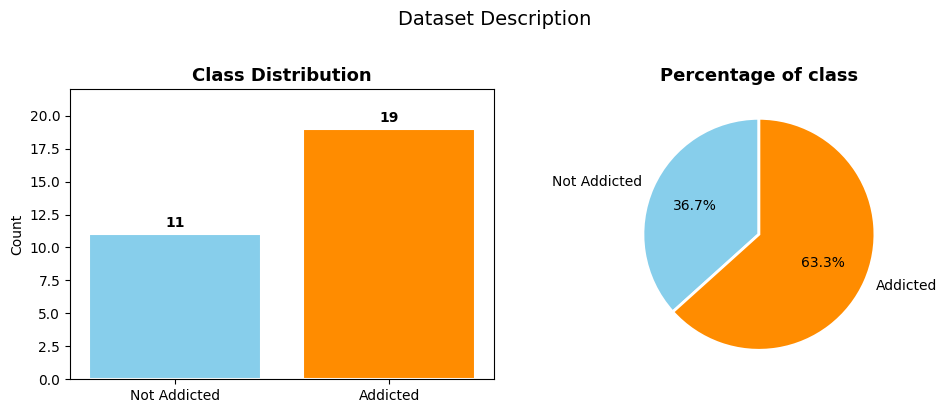

In [30]:
# Target class distribution
labels = ['Not Addicted', 'Addicted']
counts = [(df['target'] == "No, I don't").sum(), (df['target'] == "Yes, I do.").sum()]
colors = ['skyblue', 'darkorange']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
bars = axes[0].bar(labels, counts, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, max(counts) + 3)
for bar, cnt in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(cnt), ha='center', va='bottom', fontweight='bold')

# Pie chart
axes[1].pie(counts, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Percentage of class', fontsize=13, fontweight='bold')

plt.suptitle('Dataset Description', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## 4. Check raw values

In [31]:

for col in df.columns[1:]:
    print(f"\n{col}")
    print(df[col].unique())



hours_spend_per_day
['1-2 hours' '3-4 hours' '5 or more hours']

check_freq
['Only when I get notifications' 'Every 15-30 minutes' 'Every hour'
 'Rarely or never' 'Every 5 minutes']

class_use
['Occasionally' 'Rarely' 'Frequently' 'Always']

entertainment
['Less than 1 hour' '1-2 hours' '3-4 hours' '5 or more hours']

dependency
['Slightly' 'Moderately' 'Very much' 'Absolutely' 'Not at all']

check_without_noti
['Rarely' 'Frequently' 'Occasionally' 'Never' 'Always']

before_bed
['Always' 'Frequently' 'Sometimes' 'Never' 'Rarely']

target
["No, I don't" 'Yes, I do.']


## 5. Clean and convert text to numbers

In [32]:

hours_map = {
    "1-2 hours": 1,
    "3-4 hours": 2,
    "5 or more hours": 3
}

check_map = {
    "Rarely or never": 0,
    "Only when I get notifications": 1,
    "Every hour": 2,
    "Every 15-30 minutes": 3,
    "Every 5 minutes": 4
}

class_use_map = {
    "Rarely": 0,
    "Occasionally": 1,
    "Frequently": 2,
    "Always": 3
}

entertainment_map = {
    "Less than 1 hour": 0,
    "1-2 hours": 1,
    "3-4 hours": 2,
    "5 or more hours": 3
}

dependency_map = {
    "Not at all": 0,
    "Slightly": 1,
    "Moderately": 2,
    "Very much": 3,
    "Absolutely": 4
}

check_without_noti_map = {
    "Never": 0,
    "Rarely": 1,
    "Occasionally": 2,
    "Frequently": 3,
    "Always": 4
}

before_bed_map = {
    "Never": 0,
    "Rarely": 1,
    "Sometimes": 2,
    "Frequently": 3,
    "Always": 4
}

target_map = {
    "No, I don't": 0,
    "Yes, I do.": 1
}

df["hours_spend_per_day"] = df["hours_spend_per_day"].map(hours_map)
df["check_freq"] = df["check_freq"].map(check_map)
df["class_use"] = df["class_use"].map(class_use_map)
df["entertainment"] = df["entertainment"].map(entertainment_map)
df["dependency"] = df["dependency"].map(dependency_map)
df["check_without_noti"] = df["check_without_noti"].map(check_without_noti_map)
df["before_bed"] = df["before_bed"].map(before_bed_map)
df["target"] = df["target"].map(target_map)

df = df.dropna().reset_index(drop=True)

df


,timestamp,hours_spend_per_day,check_freq,class_use,entertainment,dependency,check_without_noti,before_bed,target
0,3/25/2026 14:58:57,1,1,1,0,1,1,4,0
1,3/25/2026 15:13:28,2,1,0,1,2,1,3,1
2,3/25/2026 15:13:33,3,3,2,2,3,3,4,1
3,3/25/2026 15:20:00,3,2,1,2,3,3,4,1
4,3/25/2026 15:21:48,1,1,1,1,1,1,3,1
5,3/25/2026 15:26:45,2,1,1,3,2,2,3,1
6,3/25/2026 15:36:09,1,1,0,1,2,1,2,0
7,3/25/2026 16:05:13,2,3,0,0,1,1,0,0
8,3/25/2026 16:06:18,1,2,0,0,1,1,3,0
9,3/25/2026 16:07:49,3,2,3,2,4,3,4,1


## 6. Basic information

In [33]:

print("Shape:", df.shape)
print()
print(df.info())
print()
print(df.describe())


Shape: (30, 9)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   timestamp            30 non-null     object
 1   hours_spend_per_day  30 non-null     int64 
 2   check_freq           30 non-null     int64 
 3   class_use            30 non-null     int64 
 4   entertainment        30 non-null     int64 
 5   dependency           30 non-null     int64 
 6   check_without_noti   30 non-null     int64 
 7   before_bed           30 non-null     int64 
 8   target               30 non-null     int64 
dtypes: int64(8), object(1)
memory usage: 2.2+ KB
None

       hours_spend_per_day  check_freq  class_use  entertainment  dependency  \
count            30.000000   30.000000  30.000000      30.000000   30.000000   
mean              2.066667    2.166667   1.233333       1.300000    2.166667   
std               0.784915    1.019917   1.0063

## 7. Data Visualization

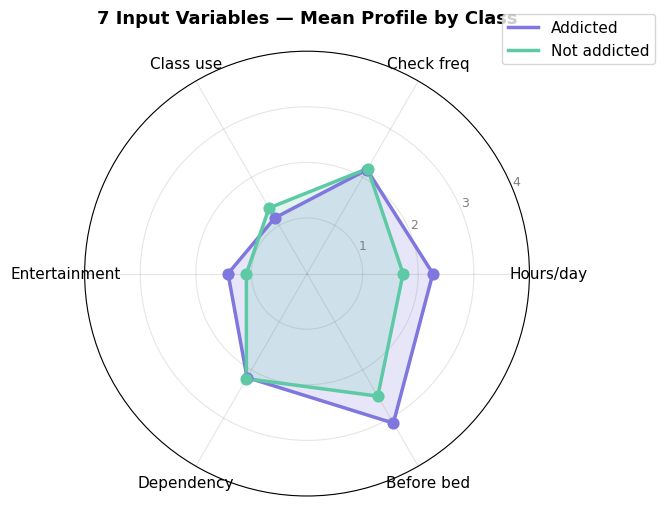

In [34]:
feature_cols = ['hours_spend_per_day', 'check_freq', 'class_use',
                'entertainment', 'dependency', 'before_bed']
labels = ['Hours/day', 'Check freq', 'Class use',
          'Entertainment', 'Dependency', 'Before bed']

addicted     = df[df['target'] == 1][feature_cols].mean().values
not_addicted = df[df['target'] == 0][feature_cols].mean().values

N = len(labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

addicted_vals     = addicted.tolist()     + addicted[:1].tolist()
not_addicted_vals = not_addicted.tolist() + not_addicted[:1].tolist()

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

ax.plot(angles, addicted_vals,     color='#7F77DD', linewidth=2.5, label='Addicted')
ax.fill(angles, addicted_vals,     color='#7F77DD', alpha=0.18)
ax.plot(angles, not_addicted_vals, color='#5DCAA5', linewidth=2.5, label='Not addicted')
ax.fill(angles, not_addicted_vals, color='#5DCAA5', alpha=0.18)

ax.scatter(angles[:-1], addicted_vals[:-1],     color='#7F77DD', s=60, zorder=5)
ax.scatter(angles[:-1], not_addicted_vals[:-1], color='#5DCAA5', s=60, zorder=5)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 4)
ax.set_yticks([1,  2, 3, 4])
ax.set_yticklabels(['1', '2', '3', '4'], fontsize=9, color='gray')
ax.grid(color='gray', alpha=0.2)

ax.set_title('7 Input Variables — Mean Profile by Class',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)

plt.tight_layout()
plt.show()

## 8. Correlation heatmap

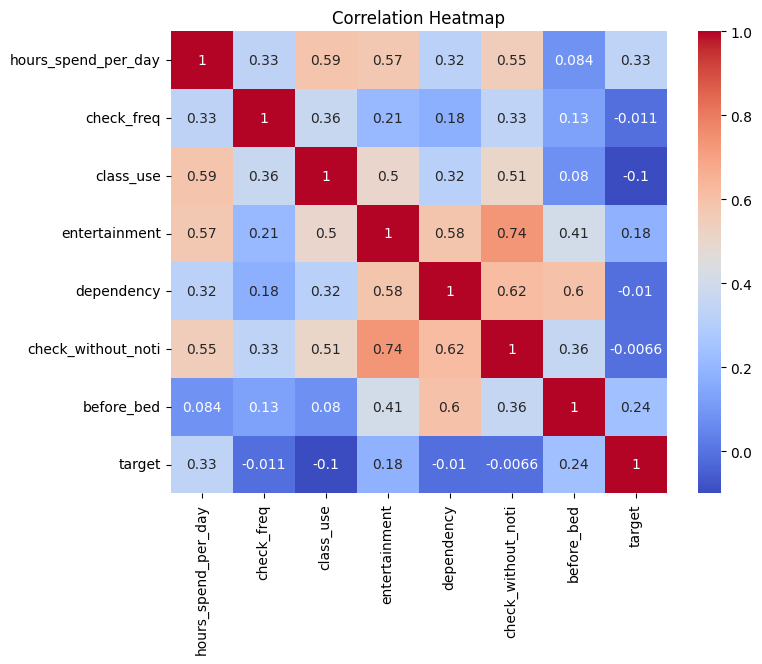

In [35]:

plt.figure(figsize=(8, 6))
sns.heatmap(df.drop(columns=["timestamp"]).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


## 9. Prepare X and y

In [36]:

feature_cols = [
    "hours_spend_per_day",
    # "check_freq",
    "class_use",
    "entertainment",
    "dependency",
    "check_without_noti",
    "before_bed"
]

X = df[feature_cols].values.astype(float)
y = df["target"].values.astype(int).reshape(-1, 1)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (30, 6)
y shape: (30, 1)



## 10. Manual train/test split from scratch

No `train_test_split()` is used here.


In [37]:

np.random.seed(42)

n_samples = len(X)
indices = np.random.permutation(n_samples)

train_ratio = 0.8
train_size = int(train_ratio * n_samples)

train_idx = indices[:train_size]
test_idx = indices[train_size:]

X_train = X[train_idx]
X_test = X[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])
print()
print("Train indices:", train_idx)
print("Test indices:", test_idx)


Train size: 24
Test size: 6

Train indices: [27 15 23 17  8  9 28 24 12  0  4 16  5 13 11 22  1  2 25  3 21 26 18 29]
Test indices: [20  7 10 14 19  6]



## 11. Feature scaling

Important: use only the **training set mean and std**.
Then use the same values to scale the test set.


In [38]:

x_mean = np.mean(X_train, axis=0)
x_std = np.std(X_train, axis=0)

x_std[x_std == 0] = 1

X_train_scal = (X_train - x_mean) / x_std
X_test_scal = (X_test - x_mean) / x_std

print("First 5 scaled train rows:")
print(X_train_scal[:5])


First 5 scaled train rows:
[[ 1.12089708  0.56628889  1.74172714  1.55563492  1.78281162  0.90119626]
 [-0.16012815 -0.47916753  0.64168895 -0.14142136  0.87243973 -0.12874232]
 [-0.16012815 -0.47916753 -1.55838744 -0.98994949 -0.03793216 -0.12874232]
 [-0.16012815 -0.47916753 -0.45834925 -0.14142136 -0.03793216 -0.12874232]
 [-1.44115338 -1.52462395 -1.55838744 -0.98994949 -0.94830405 -0.12874232]]


## 12. Add bias column

In [39]:

X_train_new = np.concatenate((np.ones((X_train_scal.shape[0], 1)), X_train_scal), axis=1)
X_test_new = np.concatenate((np.ones((X_test_scal.shape[0], 1)), X_test_scal), axis=1)

print("X_train_new shape:", X_train_new.shape)
print("X_test_new shape:", X_test_new.shape)


X_train_new shape: (24, 7)
X_test_new shape: (6, 7)


## 13. Logistic regression functions from scratch

In [40]:

def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))


def cost_function(X, y, theta):
    m = len(y)
    h = sigmoid(np.matmul(X, theta))
    eps = 1e-10
    cost = -(1 / m) * np.sum(y * np.log(h + eps) + (1 - y) * np.log(1 - h + eps))
    return cost


def gradient(X, y, theta):
    m = len(y)
    h = sigmoid(np.matmul(X, theta))
    grad = (1 / m) * np.matmul(X.T, (h - y))
    return grad


## 14. Training with gradient descent

In [41]:

theta = np.zeros((X_train_new.shape[1], 1))
lr = 0.1
iterations = 10000

cost_hist = []

for i in range(iterations):
    grad = gradient(X_train_new, y_train, theta)
    theta = theta - lr * grad

    cost = cost_function(X_train_new, y_train, theta)
    cost_hist.append(cost)

    print(f"Iteration {i}, Cost: {cost:.4f}")



Iteration 0, Cost: 0.6864
Iteration 1, Cost: 0.6799
Iteration 2, Cost: 0.6736
Iteration 3, Cost: 0.6676
Iteration 4, Cost: 0.6618
Iteration 5, Cost: 0.6562
Iteration 6, Cost: 0.6507
Iteration 7, Cost: 0.6454
Iteration 8, Cost: 0.6403
Iteration 9, Cost: 0.6354
Iteration 10, Cost: 0.6306
Iteration 11, Cost: 0.6259
Iteration 12, Cost: 0.6214
Iteration 13, Cost: 0.6170
Iteration 14, Cost: 0.6128
Iteration 15, Cost: 0.6086
Iteration 16, Cost: 0.6046
Iteration 17, Cost: 0.6006
Iteration 18, Cost: 0.5968
Iteration 19, Cost: 0.5930
Iteration 20, Cost: 0.5894
Iteration 21, Cost: 0.5858
Iteration 22, Cost: 0.5824
Iteration 23, Cost: 0.5790
Iteration 24, Cost: 0.5757
Iteration 25, Cost: 0.5725
Iteration 26, Cost: 0.5693
Iteration 27, Cost: 0.5662
Iteration 28, Cost: 0.5632
Iteration 29, Cost: 0.5603
Iteration 30, Cost: 0.5574
Iteration 31, Cost: 0.5546
Iteration 32, Cost: 0.5518
Iteration 33, Cost: 0.5491
Iteration 34, Cost: 0.5465
Iteration 35, Cost: 0.5439
Iteration 36, Cost: 0.5414
Iteration 3

In [42]:
print("Final theta:")
print(theta)

Final theta:
[[ 3.64204791]
 [10.10863553]
 [-3.93360086]
 [ 4.28300078]
 [-5.48092403]
 [-6.307165  ]
 [ 3.03746603]]


## 15. Plot cost history

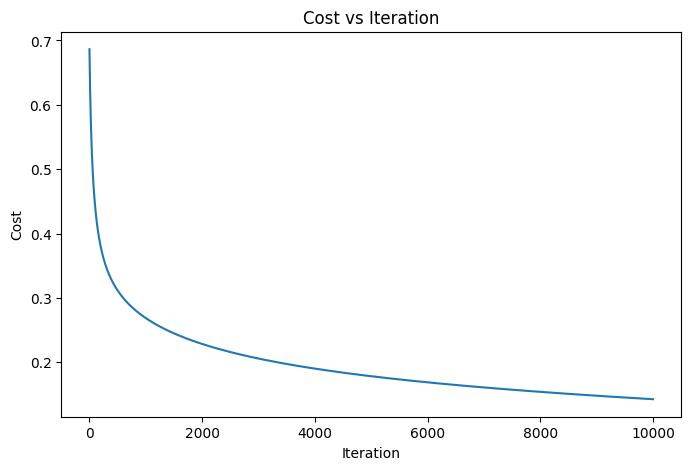

In [43]:

plt.figure(figsize=(8, 5))
plt.plot(cost_hist)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost vs Iteration")
plt.show()


## 16. Predict train and test

In [44]:

train_probs = sigmoid(np.matmul(X_train_new, theta))
test_probs = sigmoid(np.matmul(X_test_new, theta))

train_pred = (train_probs >= 0.5).astype(int)
test_pred = (test_probs >= 0.5).astype(int)

print("Train probabilities:")
print(train_probs[:5].ravel())

print()
print("Test probabilities:")
print(test_probs[:5].ravel())


Train probabilities:
[0.95975149 0.82317769 0.92467859 0.92880181 0.35721756]

Test probabilities:
[1.81050943e-05 9.51512439e-01 8.94472324e-01 9.99726285e-01
 9.99999695e-01]


## 17. Accuracy from scratch

In [45]:

train_acc = np.mean(train_pred == y_train)
test_acc = np.mean(test_pred == y_test)

print("Train Accuracy:", train_acc*100, "%")
print("Test Accuracy:", test_acc*100, "%")

Train Accuracy: 100.0 %
Test Accuracy: 66.66666666666666 %


## 18. Confusion matrix from scratch

In [46]:

def confusion_matrix_binary(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return tp, tn, fp, fn

tp, tn, fp, fn = confusion_matrix_binary(y_test, test_pred)

print("TP =", int(tp))
print("TN =", int(tn))
print("FP =", int(fp))
print("FN =", int(fn))

cm = np.array([[tp, fp],
               [fn, tn]])

print()
print("Confusion Matrix:")
print(cm)


TP = 3
TN = 1
FP = 1
FN = 1

Confusion Matrix:
[[3 1]
 [1 1]]


## 19. Precision, recall, F1 from scratch

In [47]:

precision = tp / (tp + fp) if (tp + fp) != 0 else 0
recall = tp / (tp + fn) if (tp + fn) != 0 else 0
f1_score = (2 * precision * recall / (precision + recall)) if (precision + recall) != 0 else 0

print("Precision:", precision*100, "%")
print("Recall:", recall*100, "%")
print("F1-score:", f1_score*100, "%")

Precision: 75.0 %
Recall: 75.0 %
F1-score: 75.0 %


## 20. Show actual vs predicted

In [48]:

result_df = pd.DataFrame({
    "Actual": y_test.ravel(),
    "Predicted": test_pred.ravel(),
    "Probability": test_probs.ravel()
})

result_df


,Actual,Predicted,Probability
0,1,0,0.000018
1,0,1,0.951512
2,1,1,0.894472
3,1,1,0.999726
4,1,1,1.000000
5,0,0,0.025207


## 21. Example prediction for one new student

In [49]:

new_student = np.array([[3, 3, 2, 3, 4, 4]], dtype=float)

new_student_scal = (new_student - x_mean) / x_std
new_student_new = np.concatenate((np.ones((1, 1)), new_student_scal), axis=1)

new_prob = sigmoid(np.matmul(new_student_new, theta))
new_pred = (new_prob >= 0.5).astype(int)

print("Predicted probability:", float(new_prob.item()))
print("Predicted class:", int(new_pred.item()))

if int(new_pred.item()) == 1:
    print("Prediction: Addicted")
else:
    print("Prediction: Not addicted")


Predicted probability: 0.26863616899684784
Predicted class: 0
Prediction: Not addicted


In [50]:
import pickle
import os

# Save model parameters
model_data = {
    'theta': theta,
    'x_mean': x_mean,
    'x_std': x_std
}

# Save to the same directory as the notebook
save_path = '/Users/macbook/Desktop/IML_P2/model.pkl'

with open(save_path, 'wb') as f:
    pickle.dump(model_data, f)

print(f"✅ Model saved successfully to: {save_path}")
print(f"Model parameters saved:")
print(f"  - theta shape: {theta.shape}")
print(f"  - x_mean shape: {x_mean.shape}")
print(f"  - x_std shape: {x_std.shape}")

✅ Model saved successfully to: /Users/macbook/Desktop/IML_P2/model.pkl
Model parameters saved:
  - theta shape: (7, 1)
  - x_mean shape: (6,)
  - x_std shape: (6,)
